# Forecasting: Monthly Revenue Prediction
## Enterprise Predictive Analytics Engine — E-commerce Domain

**Objective:** Forecast monthly revenue for the next 6 months using
historical order data, with confidence intervals to support business
planning decisions.

**Input:** `data/processed/olist_master_cleaned.csv`

## 1. Load and Aggregate Monthly Revenue

Olist data covers Sept 2016 - Oct 2018. We aggregate order-level revenue
into monthly totals — the format Prophet expects (a time series with one
row per time period).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/olist_master_cleaned.csv", parse_dates=["order_purchase_timestamp"])

# Aggregate to monthly revenue (using payment_value, only delivered orders for reliability)
monthly_revenue = (
    df[df["is_delivered"] == True]
    .set_index("order_purchase_timestamp")
    .resample("MS")["payment_value"]
    .sum()
    .reset_index()
)
monthly_revenue.columns = ["ds", "y"]

print("Monthly revenue shape:", monthly_revenue.shape)
monthly_revenue.head(10)


Monthly revenue shape: (24, 2)


,ds,y
0,2016-09-01,0.00
1,2016-10-01,61746.94
2,2016-11-01,0.00
3,2016-12-01,19.62
4,2017-01-01,176491.49
5,2017-02-01,325782.66
6,2017-03-01,505735.83
7,2017-04-01,456108.32
8,2017-05-01,701313.60
9,2017-06-01,585400.98


## 2. Clean the Time Series for Forecasting

The first few months (Sept-Dec 2016) show near-zero revenue — this
reflects Olist's platform launch period, not a real demand pattern, and
would distort the forecast if included. We trim the series to start from
January 2017, once order volume stabilizes.

In [5]:
# Trim the unstable launch period (keep from Jan 2017 onward)
monthly_revenue_clean = monthly_revenue[monthly_revenue["ds"] >= "2017-01-01"].reset_index(drop=True)

# Check if the last month looks incomplete by comparing order counts per month
order_counts = (
    df[df["is_delivered"] == True]
    .set_index("order_purchase_timestamp")
    .resample("MS")["order_id"]
    .count()
)
print(order_counts.tail(6))

print("\nCleaned series shape:", monthly_revenue_clean.shape)
monthly_revenue_clean

order_purchase_timestamp
2018-03-01    8017
2018-04-01    7827
2018-05-01    7810
2018-06-01    7010
2018-07-01    6963
2018-08-01    7142
Freq: MS, Name: order_id, dtype: int64

Cleaned series shape: (20, 2)


,ds,y
0,2017-01-01,176491.49
1,2017-02-01,325782.66
2,2017-03-01,505735.83
3,2017-04-01,456108.32
4,2017-05-01,701313.60
5,2017-06-01,585400.98
6,2017-07-01,716069.98
7,2017-08-01,842689.94
8,2017-09-01,996279.59
9,2017-10-01,998609.62


## 3. Train the Forecasting Model with Prophet

Prophet is well-suited for business time series — it handles trend and
seasonality automatically and produces confidence intervals out of the
box, which the brief specifically requires.

In [6]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=False,  # disabled - insufficient data (only 20 months) to reliably estimate
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.90
)

model.fit(monthly_revenue_clean)
print("Model trained successfully")

16:47:03 - cmdstanpy - INFO - Chain [1] start processing
16:47:04 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully


## 4. Generate Forecast with Confidence Intervals

Forecasting the next 6 months beyond the historical data, with 90%
confidence intervals (upper and lower bounds) as required by the brief.

**Note:** Yearly seasonality was disabled in the model (Section 3) since
only 20 months of historical data are available — not enough to reliably
estimate a yearly pattern (Prophet recommends at least 2 full years).

In [7]:
future = model.make_future_dataframe(periods=6, freq="MS")
forecast = model.predict(future)

forecast_display = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(6)
forecast_display.columns = ["Month", "Predicted Revenue", "Lower Bound (90%)", "Upper Bound (90%)"]
forecast_display

,Month,Predicted Revenue,Lower Bound (90%),Upper Bound (90%)
20,2018-09-01,1.655885e+06,1.342108e+06,1.955492e+06
21,2018-10-01,1.718746e+06,1.393638e+06,2.038839e+06
22,2018-11-01,1.783702e+06,1.477573e+06,2.072597e+06
23,2018-12-01,1.846563e+06,1.544663e+06,2.134434e+06
24,2019-01-01,1.911519e+06,1.580286e+06,2.221388e+06
25,2019-02-01,1.976475e+06,1.652503e+06,2.295782e+06


## 5. Visualize Historical + Forecasted Revenue

Plotting the full picture: historical actuals, the model's fitted trend,
and the 6-month forecast with confidence interval shading.

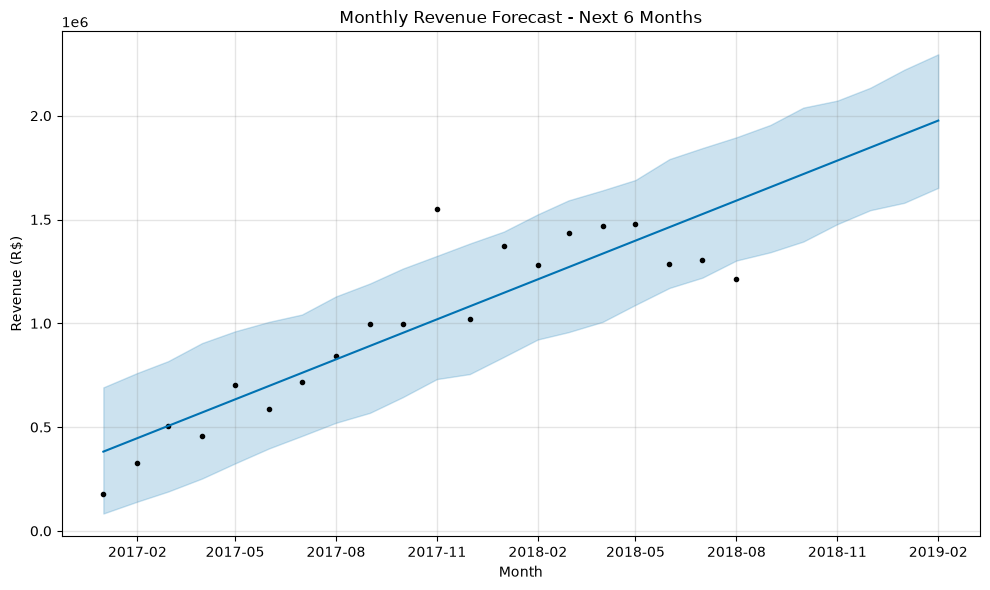

In [8]:
fig = model.plot(forecast)
plt.title("Monthly Revenue Forecast - Next 6 Months")
plt.xlabel("Month")
plt.ylabel("Revenue (R$)")
plt.tight_layout()
plt.savefig("../outputs/figures/revenue_forecast.png", dpi=100, bbox_inches="tight")
plt.show()

## 6. Save Forecast Output

Saving both the full forecast (historical fit + future predictions) for
use in the Power BI dashboard.

In [9]:
import os
os.makedirs("../data/processed", exist_ok=True)

forecast_output = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
forecast_output.columns = ["month", "predicted_revenue", "lower_bound", "upper_bound"]

# Merge with actuals for comparison
forecast_output = forecast_output.merge(
    monthly_revenue_clean.rename(columns={"ds": "month", "y": "actual_revenue"}),
    on="month", how="left"
)

forecast_output.to_csv("../data/processed/revenue_forecast.csv", index=False)
print("Saved to data/processed/revenue_forecast.csv")
forecast_output.tail(10)

Saved to data/processed/revenue_forecast.csv


,month,predicted_revenue,lower_bound,upper_bound,actual_revenue
16,2018-05-01,1.398155e+06,1.088628e+06,1.690248e+06,1480667.59
17,2018-06-01,1.463111e+06,1.170276e+06,1.791067e+06,1285926.11
18,2018-07-01,1.525972e+06,1.219722e+06,1.843916e+06,1307228.18
19,2018-08-01,1.590929e+06,1.302343e+06,1.895968e+06,1211240.09
20,2018-09-01,1.655885e+06,1.342108e+06,1.955492e+06,NaN
21,2018-10-01,1.718746e+06,1.393638e+06,2.038839e+06,NaN
22,2018-11-01,1.783702e+06,1.477573e+06,2.072597e+06,NaN
23,2018-12-01,1.846563e+06,1.544663e+06,2.134434e+06,NaN
24,2019-01-01,1.911519e+06,1.580286e+06,2.221388e+06,NaN
25,2019-02-01,1.976475e+06,1.652503e+06,2.295782e+06,NaN


## Summary

- Aggregated order data into monthly revenue (Jan 2017 - Aug 2018, 20 months,
  after trimming Olist's unstable 2016 launch period)
- Trained a Prophet forecasting model with 90% confidence intervals
- Disabled yearly seasonality due to insufficient data (only 20 months) to
  reliably estimate a yearly pattern
- **6-month forecast (Sept 2018 - Feb 2019):** revenue projected to grow
  from ~R$1.66M to ~R$1.98M, continuing the steady upward trend seen
  throughout 2017-2018
- Confidence bands are moderately wide (~±300-320k, roughly 18-20% of the
  point estimate), reflecting real uncertainty given limited historical
  data — appropriate for planning purposes but not precise budgeting
- Forecast output saved for downstream use in the Power BI dashboard
  (`data/processed/revenue_forecast.csv`)